In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# load data
file_path = "../data/qwen_model/checkpoint-6400_modifiedprompt/trainer_state.json" 
with open(file_path, 'r') as f:
    data = json.load(f)

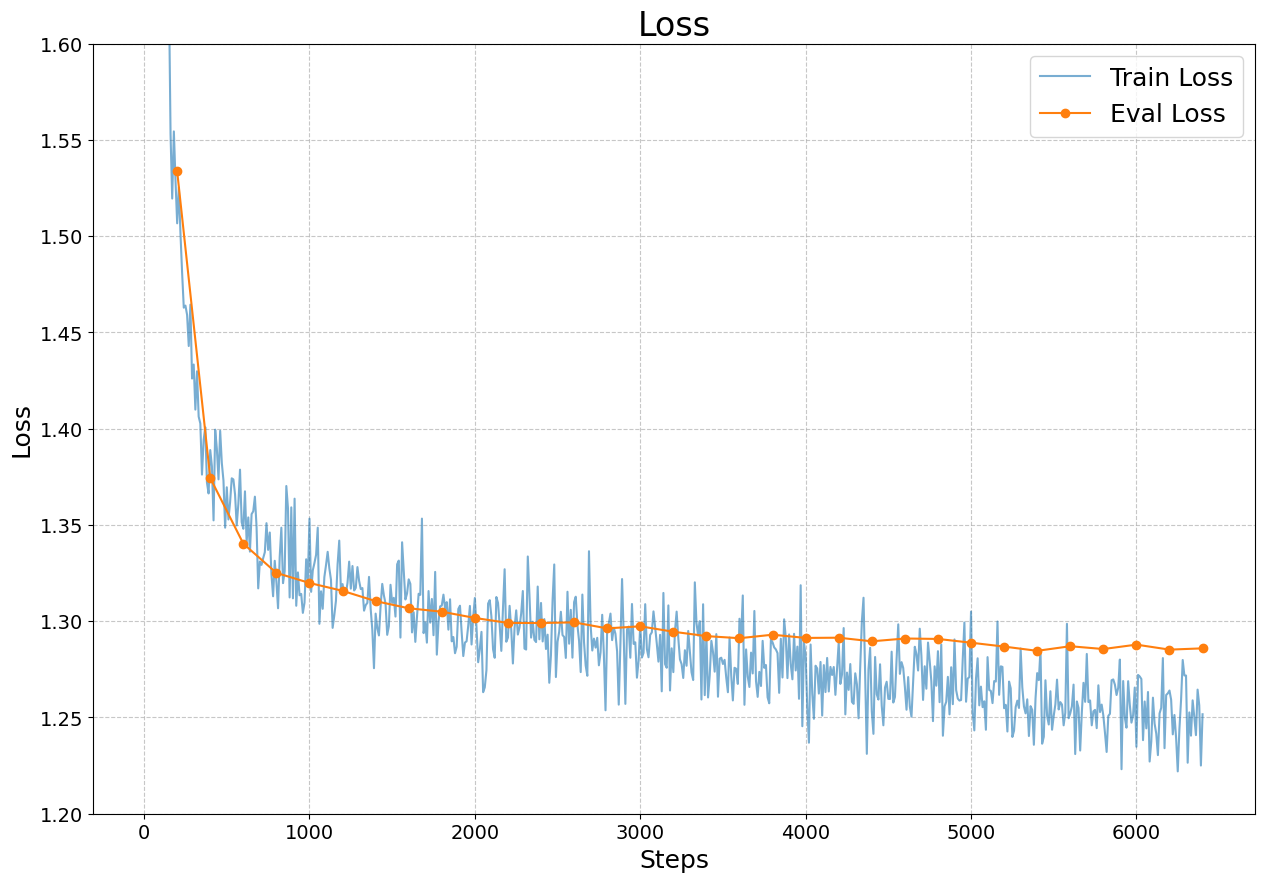

In [ ]:
# to pd df
df = pd.DataFrame(data['log_history'])

# seperate train and eval (loss)
train_df = df[df['loss'].notna()].copy()
eval_df = df[df['eval_loss'].notna()].copy()

# create plot
fig, (ax1) = plt.subplots(1, figsize=(15, 10))

ax1.plot(train_df['step'], train_df['loss'], label='Train Loss', alpha=0.6)
if not eval_df.empty:
    ax1.plot(eval_df['step'], eval_df['eval_loss'], label='Eval Loss', marker='o')
ax1.set_title('Loss', fontsize=24)
ax1.set_xlabel('Steps', fontsize=18)
ax1.set_ylabel('Loss', fontsize=18)
ax1.legend(fontsize=18)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_ylim(1.2, 1.6)
ax1.tick_params(axis='both', which='major', labelsize=14)



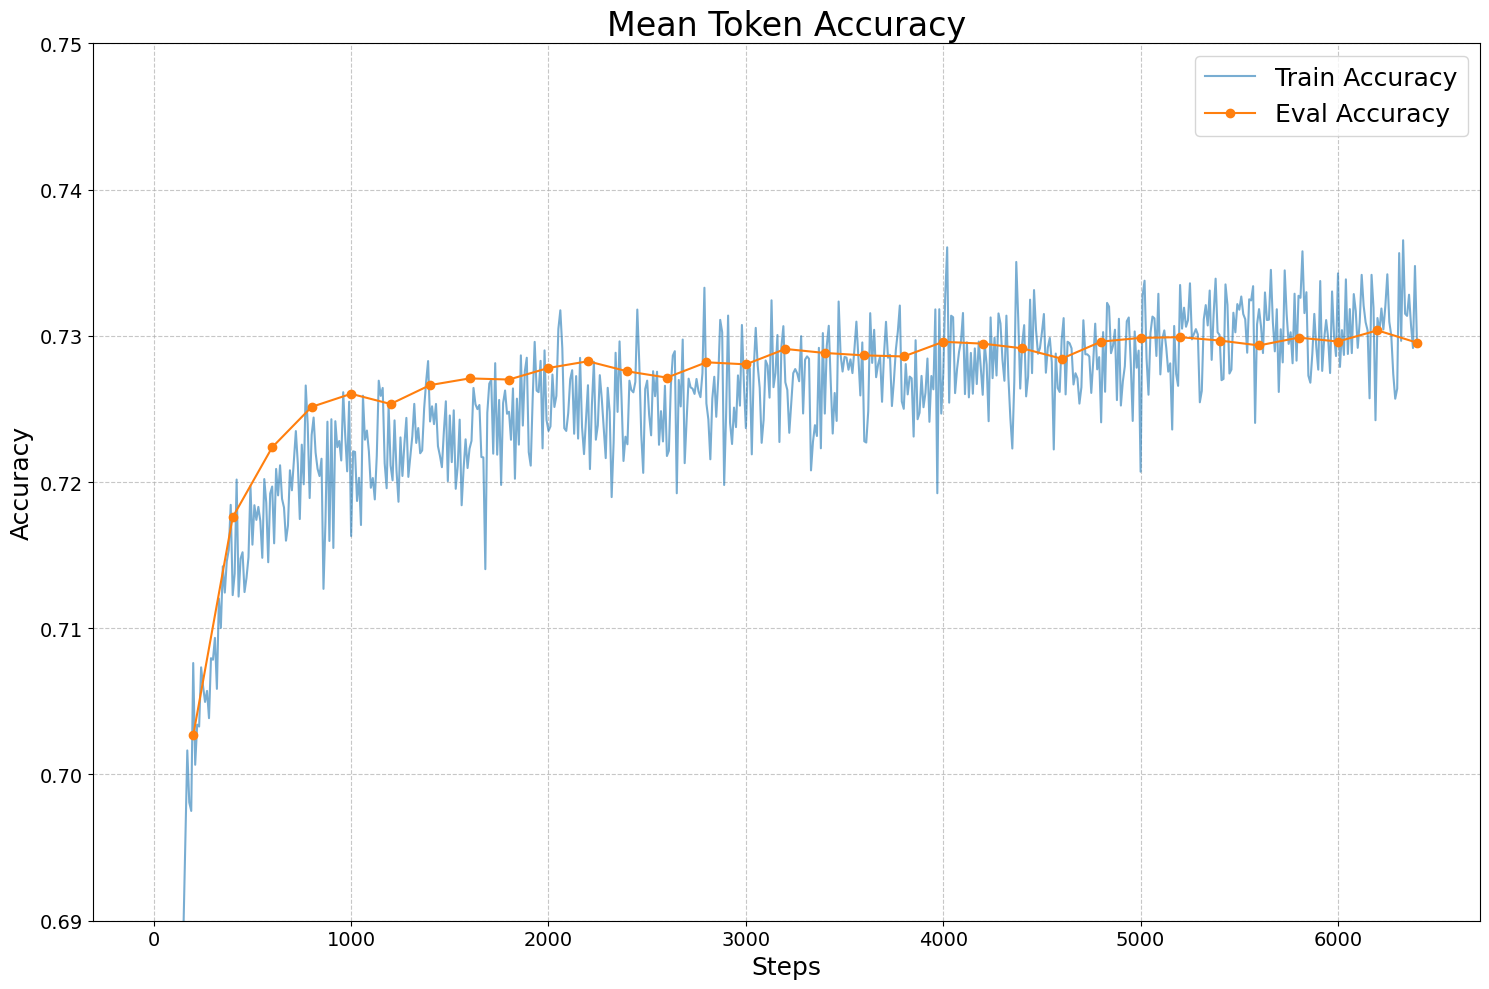

In [ ]:
# plot accuracy
fig, (ax2) = plt.subplots(1, figsize=(15, 10))

if 'mean_token_accuracy' in train_df.columns:
    ax2.plot(train_df['step'], train_df['mean_token_accuracy'], label='Train Accuracy', alpha=0.6)
if not eval_df.empty and 'eval_mean_token_accuracy' in eval_df.columns:
    ax2.plot(eval_df['step'], eval_df['eval_mean_token_accuracy'], label='Eval Accuracy', marker='o')

ax2.set_title('Mean Token Accuracy', fontsize=24)
ax2.set_xlabel('Steps', fontsize=18)
ax2.set_ylabel('Accuracy', fontsize=18)
ax2.legend(fontsize=18)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_ylim(0.69,0.75)
ax2.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

In [30]:
print(f"Bester Step: {data.get('best_global_step')}")
print(f"Beste Metrik: {data.get('best_metric'):.4f}")


Bester Step: 6400
Beste Metrik: 1.3858
